# Decision Tree Classification: Seattle Weather Dataset

## Objetivo
Desarrollar un modelo de clasificación con Decision Trees usando el dataset de clima de Seattle. Aprenderemos a:
- Analizar el balance de clases
- Aplicar técnicas de balanceo
- Construir y optimizar modelos
- Comparar resultados

## Resumen Ejecutivo

En esta actividad construimos un clasificador de Decision Tree para predecir 5 tipos de clima en Seattle (rain, sun, drizzle, snow, fog) usando variables meteorológicas. Enfrentamos el desafío del **desbalanceo de clases** aplicando oversampling, y comparamos dos enfoques: un modelo baseline sin restricciones y uno optimizado vía GridSearchCV. Ambos lograron **93.24% de accuracy**, demostrando la efectividad de las variables predictoras. El análisis incluye visualizaciones del árbol, matrices de confusión, y métricas detalladas para cada clase, proporcionando insights sobre cuándo y por qué el modelo comete errores.

## Parte 1: Carga de datos y análisis de balance de clases

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Cargar dataset (ignorando la columna date)
df = pd.read_csv('../../data/s2/seattle-weather.csv')
df = df.drop('date', axis=1)

print("Primeras filas del dataset:")
print(df.head())
print(f"\nDimensiones: {df.shape}")
print(f"\nInformación del dataset:")
print(df.info())

Primeras filas del dataset:
   precipitation  temp_max  temp_min  wind  weather
0            0.0      12.8       5.0   4.7  drizzle
1           10.9      10.6       2.8   4.5     rain
2            0.8      11.7       7.2   2.3     rain
3           20.3      12.2       5.6   4.7     rain
4            1.3       8.9       2.8   6.1     rain

Dimensiones: (1461, 5)

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   precipitation  1461 non-null   float64
 1   temp_max       1461 non-null   float64
 2   temp_min       1461 non-null   float64
 3   wind           1461 non-null   float64
 4   weather        1461 non-null   str    
dtypes: float64(4), str(1)
memory usage: 57.2 KB
None


Conteo de clases:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Proporciones (%):
weather
rain       43.874059
sun        43.805613
fog         6.913073
drizzle     3.627652
snow        1.779603
Name: proportion, dtype: float64


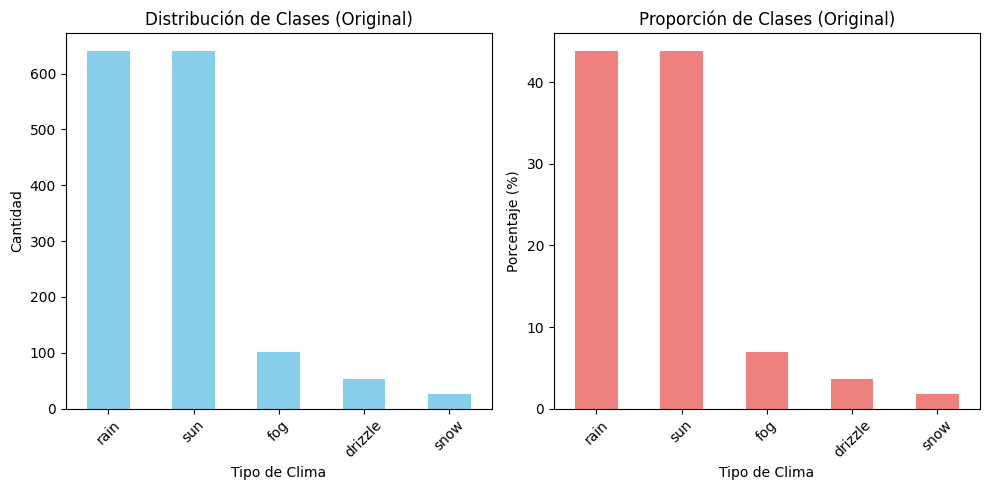


⚠️ El dataset está DESBALANCEADO


In [79]:
# Análisis de balance de clases
class_counts = df['weather'].value_counts()
class_proportions = df['weather'].value_counts(normalize=True) * 100

print("Conteo de clases:")
print(class_counts)
print("\nProporciones (%):") 
print(class_proportions)

# Visualizar distribución de clases
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color='skyblue')
plt.title('Distribución de Clases (Original)')
plt.xlabel('Tipo de Clima')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
class_proportions.plot(kind='bar', color='lightcoral')
plt.title('Proporción de Clases (Original)')
plt.xlabel('Tipo de Clima')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Determinar si está balanceado
if class_proportions.max() - class_proportions.min() > 20:
    print("\n⚠️ El dataset está DESBALANCEADO")
else:
    print("\n✓ El dataset está balanceado")

## Parte 2: Balanceo de clases

In [80]:
# Separar features y target
X = df.drop('weather', axis=1)
y = df['weather']

# Aplicar oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

print("Distribución ANTES del balanceo:")
print(y.value_counts())
print("\nDistribución DESPUÉS del balanceo:")
print(pd.Series(y_resampled).value_counts())

Distribución ANTES del balanceo:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Distribución DESPUÉS del balanceo:
weather
drizzle    641
rain       641
sun        641
snow       641
fog        641
Name: count, dtype: int64


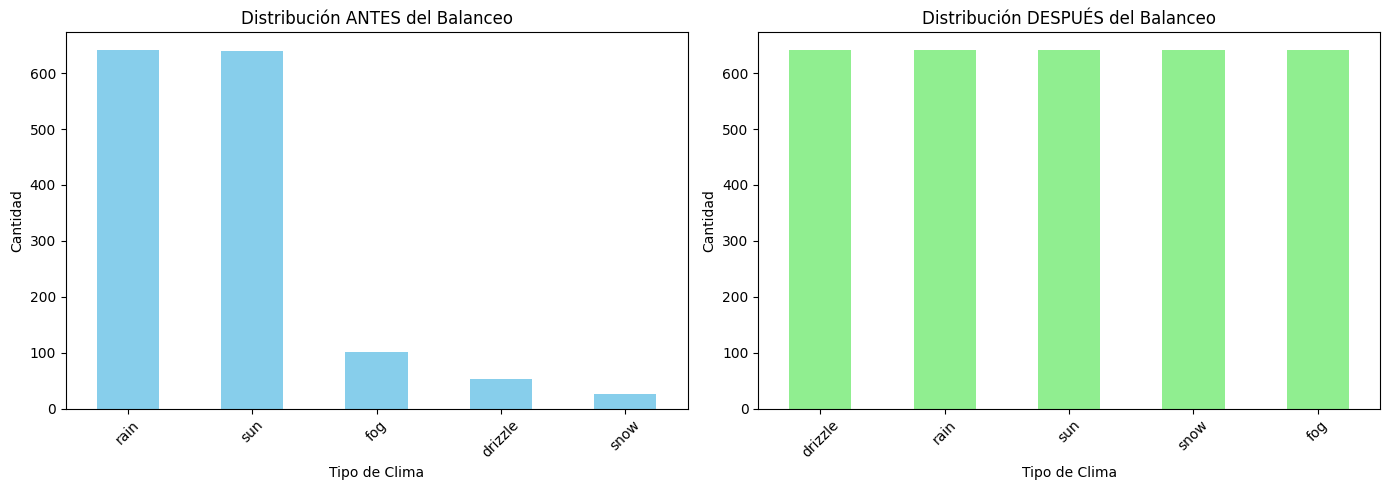

In [81]:
# Comparar distribuciones antes y después del balanceo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del balanceo
y.value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribución ANTES del Balanceo')
axes[0].set_xlabel('Tipo de Clima')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Después del balanceo
pd.Series(y_resampled).value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución DESPUÉS del Balanceo')
axes[1].set_xlabel('Tipo de Clima')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Parte 3: División de datos y modelo baseline sin optimización

In [82]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (2243, 4)
Tamaño del conjunto de prueba: (962, 4)


In [83]:
# Crear modelo baseline
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Predicciones
y_pred_baseline = dt_baseline.predict(X_test)

print("Modelo Baseline creado exitosamente")
print(f"Profundidad del árbol: {dt_baseline.get_depth()}")
print(f"Número de hojas: {dt_baseline.get_n_leaves()}")

Modelo Baseline creado exitosamente
Profundidad del árbol: 19
Número de hojas: 304


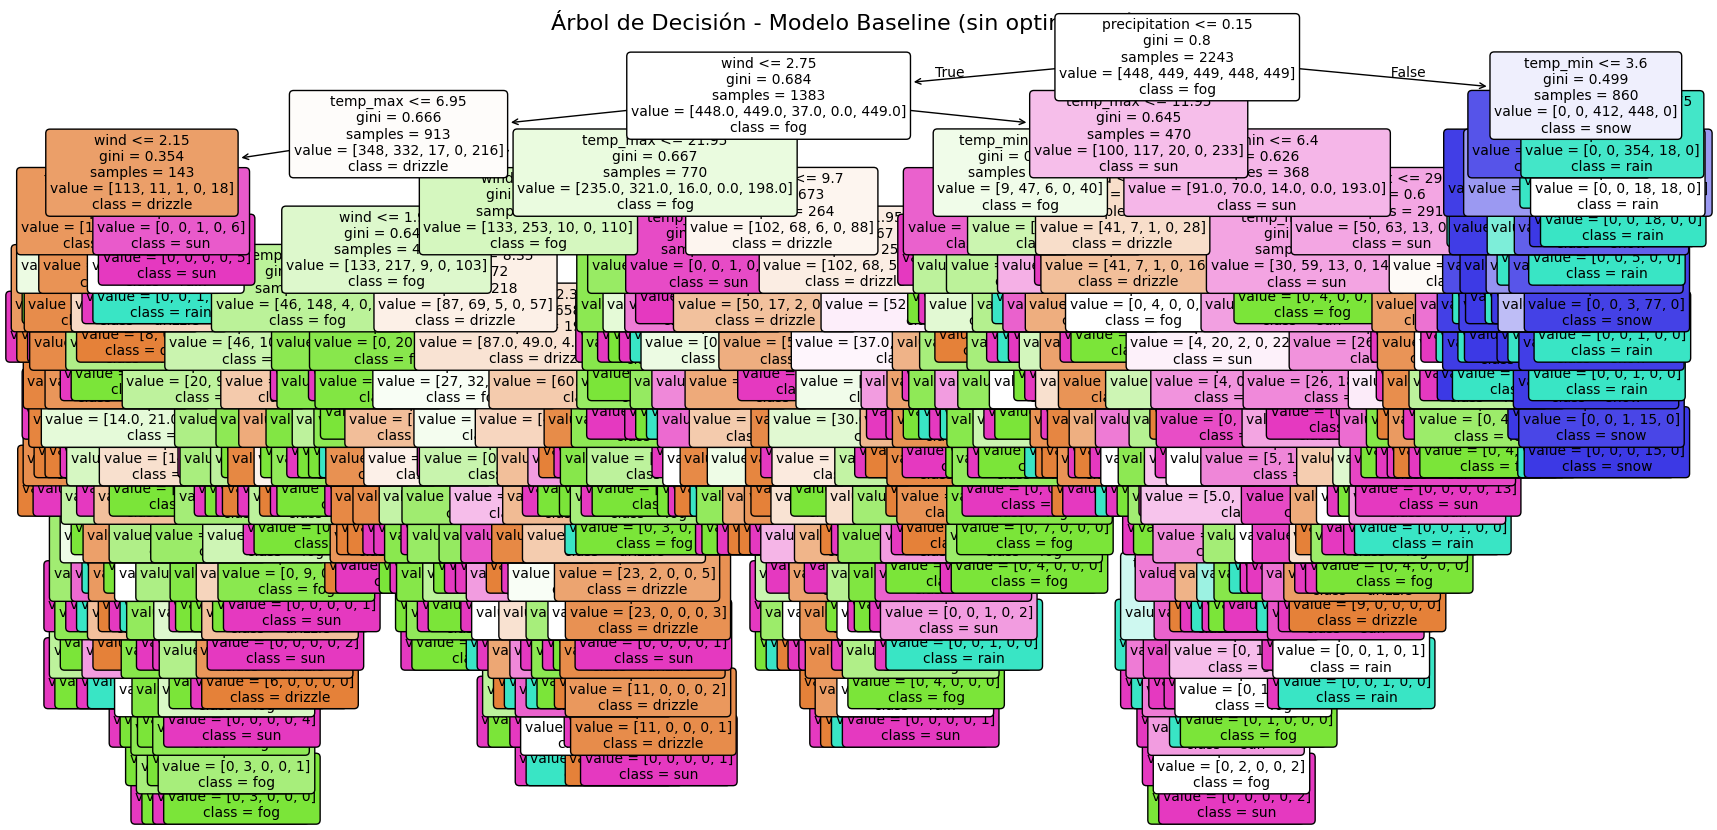

In [84]:
# Visualizar árbol de decisión baseline
plt.figure(figsize=(20, 10))
plot_tree(dt_baseline, 
          feature_names=X.columns, 
          class_names=dt_baseline.classes_, 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión - Modelo Baseline (sin optimización)', fontsize=16)
plt.show()

EVALUACIÓN DEL MODELO BASELINE

Accuracy: 0.9324

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.92      1.00      0.96       193
         fog       0.88      0.99      0.93       192
        rain       0.95      0.94      0.94       192
        snow       0.96      1.00      0.98       193
         sun       0.97      0.73      0.83       192

    accuracy                           0.93       962
   macro avg       0.94      0.93      0.93       962
weighted avg       0.94      0.93      0.93       962



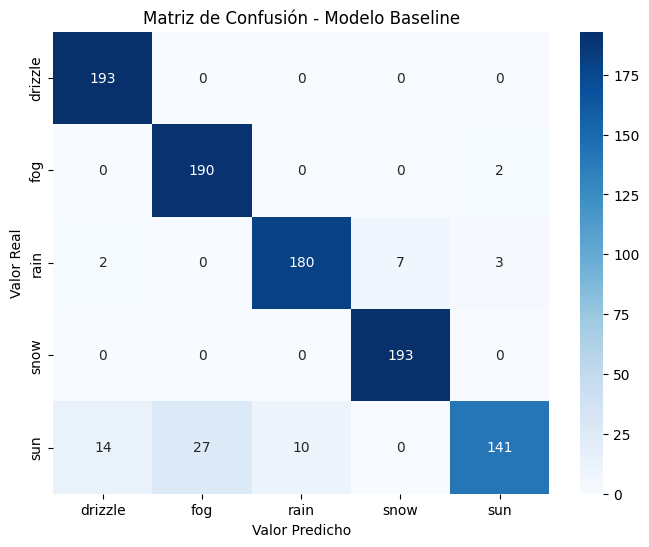

In [85]:
# Evaluación del modelo baseline
print("=" * 60)
print("EVALUACIÓN DEL MODELO BASELINE")
print("=" * 60)

# Accuracy
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"\nAccuracy: {accuracy_baseline:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

# Confusion Matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dt_baseline.classes_, 
            yticklabels=dt_baseline.classes_)
plt.title('Matriz de Confusión - Modelo Baseline')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

## Parte 4: Modelo optimizado con GridSearchCV

In [86]:
# Definir grid de hiperparámetros
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [10, 20, 50, 100, 200, 300, 400, None]
}

# Crear modelo base
dt_model = DecisionTreeClassifier(random_state=42)

# GridSearchCV
print("Iniciando búsqueda de hiperparámetros óptimos...")
print("Esto puede tomar varios minutos...")

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✓ Búsqueda completada!")

Iniciando búsqueda de hiperparámetros óptimos...
Esto puede tomar varios minutos...
Fitting 5 folds for each of 1920 candidates, totalling 9600 fits

✓ Búsqueda completada!


In [87]:
# Mejores hiperparámetros encontrados
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 60)
print(f"\nMejor combinación de parámetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nMejor score de validación cruzada: {grid_search.best_score_:.4f}")

MEJORES HIPERPARÁMETROS ENCONTRADOS

Mejor combinación de parámetros:
  - max_depth: None
  - max_features: sqrt
  - max_leaf_nodes: None
  - min_samples_leaf: 1
  - min_samples_split: 2

Mejor score de validación cruzada: 0.9197


In [88]:
# Obtener el mejor modelo y hacer predicciones
dt_optimized = grid_search.best_estimator_
y_pred_optimized = dt_optimized.predict(X_test)

print(f"Profundidad del árbol optimizado: {dt_optimized.get_depth()}")
print(f"Número de hojas: {dt_optimized.get_n_leaves()}")

Profundidad del árbol optimizado: 20
Número de hojas: 354


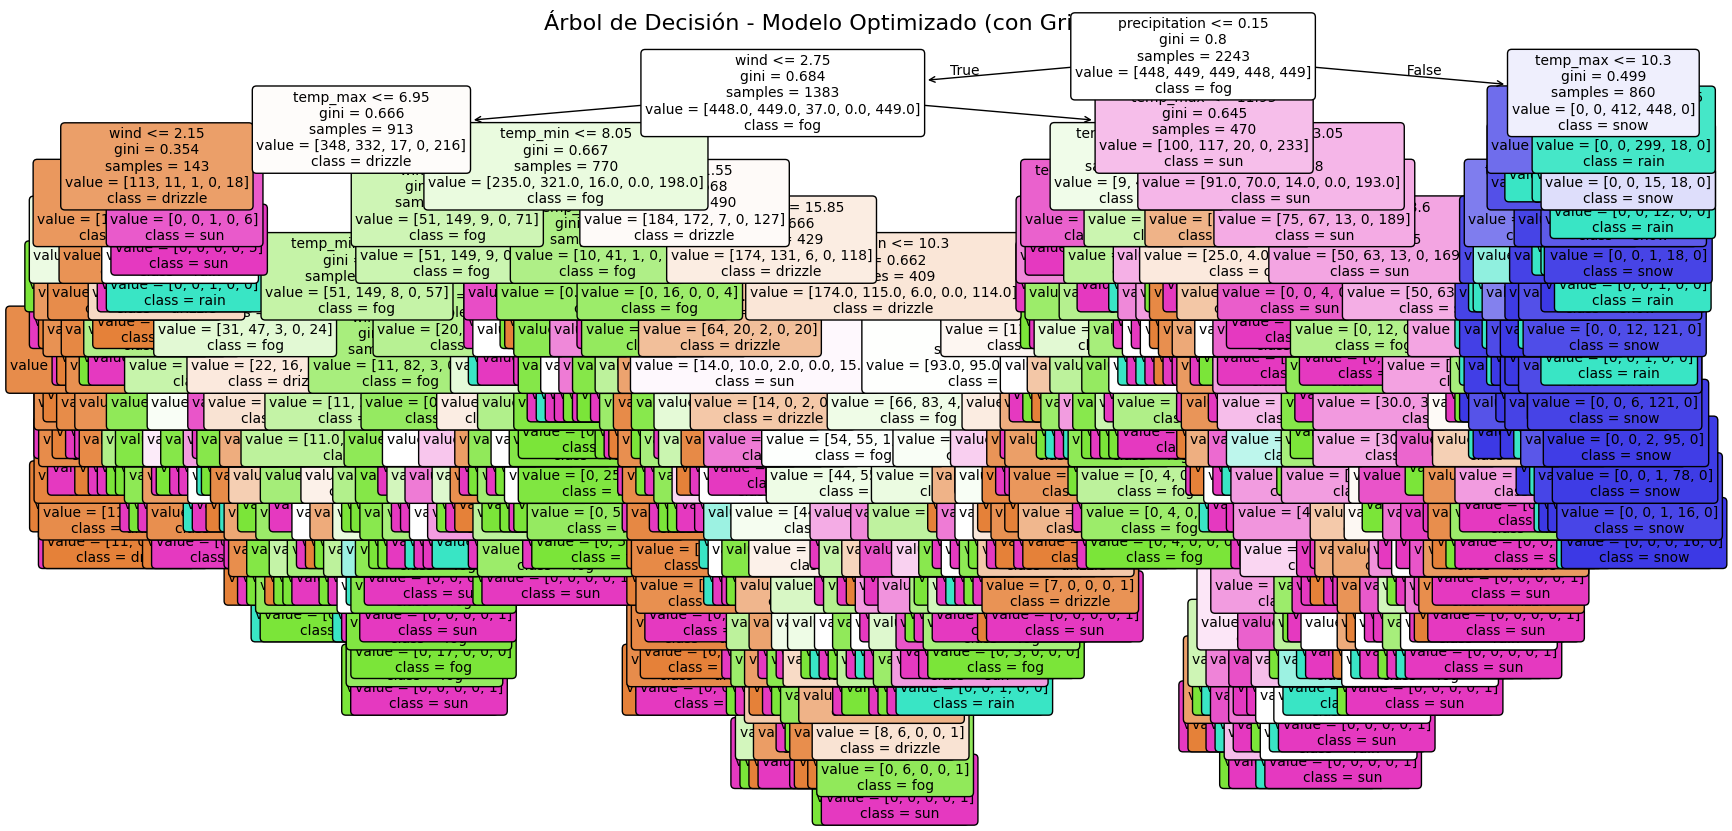

In [89]:
# Visualizar árbol de decisión optimizado
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized, 
          feature_names=X.columns, 
          class_names=dt_optimized.classes_, 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión - Modelo Optimizado (con GridSearchCV)', fontsize=16)
plt.show()

EVALUACIÓN DEL MODELO OPTIMIZADO

Accuracy: 0.9324

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.93      1.00      0.96       193
         fog       0.88      0.99      0.93       192
        rain       0.96      0.92      0.94       192
        snow       0.95      1.00      0.97       193
         sun       0.96      0.75      0.84       192

    accuracy                           0.93       962
   macro avg       0.94      0.93      0.93       962
weighted avg       0.94      0.93      0.93       962



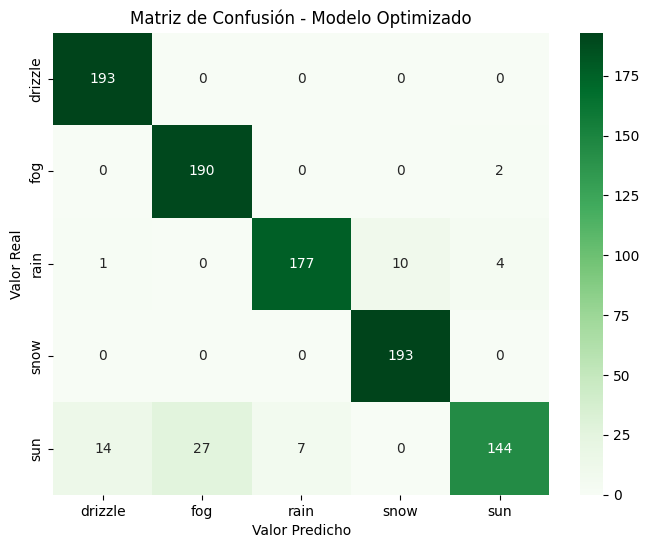

In [90]:
# Evaluación del modelo optimizado
print("=" * 60)
print("EVALUACIÓN DEL MODELO OPTIMIZADO")
print("=" * 60)

# Accuracy
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"\nAccuracy: {accuracy_optimized:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

# Confusion Matrix
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', 
            xticklabels=dt_optimized.classes_, 
            yticklabels=dt_optimized.classes_)
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

## Parte 5: Comparación de modelos y conclusiones

In [91]:
# Comparación cuantitativa
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Profundidad', 'Número de Hojas'],
    'Baseline': [
        f"{accuracy_baseline:.4f}",
        dt_baseline.get_depth(),
        dt_baseline.get_n_leaves()
    ],
    'Optimizado': [
        f"{accuracy_optimized:.4f}",
        dt_optimized.get_depth(),
        dt_optimized.get_n_leaves()
    ]
})

print("=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)
print(comparison.to_string(index=False))

# Mejora en accuracy
improvement = (accuracy_optimized - accuracy_baseline) * 100
print(f"\nMejora en Accuracy: {improvement:+.2f}%")

COMPARACIÓN DE MODELOS
        Métrica Baseline Optimizado
       Accuracy   0.9324     0.9324
    Profundidad       19         20
Número de Hojas      304        354

Mejora en Accuracy: +0.00%


In [92]:
# Análisis detallado de los resultados
print("=" * 70)
print("ANÁLISIS DE LOS HIPERPARÁMETROS ENCONTRADOS")
print("=" * 70)
print("\nHiperparámetros del modelo optimizado:")

for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print("\n" + "=" * 70)
print("INTERPRETACIÓN DE LOS RESULTADOS")
print("=" * 70)
print(f"""
Observación importante:
- El modelo optimizado tiene MAYOR complejidad que el baseline
  (Profundidad: {dt_optimized.get_depth()} vs {dt_baseline.get_depth()})
  (Hojas: {dt_optimized.get_n_leaves()} vs {dt_baseline.get_n_leaves()})

- El accuracy es idéntico ({accuracy_optimized:.4f})

Posibles explicaciones:
1. GridSearchCV puede haber encontrado que parámetros menos restrictivos
   (como max_depth=None) funcionan mejor con validación cruzada
   
2. Con los datos balanceados, un árbol más complejo no necesariamente
   causa overfitting si las clases están bien distribuidas
   
3. La diferencia puede ser más evidente en datos de producción no vistos

Recomendación:
- Evaluar en conjunto de validación adicional
- Considerar grid más restrictivo si la complejidad es preocupante
- Monitorear performance en datos nuevos
""")

ANÁLISIS DE LOS HIPERPARÁMETROS ENCONTRADOS

Hiperparámetros del modelo optimizado:
  max_depth: None
  max_features: sqrt
  max_leaf_nodes: None
  min_samples_leaf: 1
  min_samples_split: 2

INTERPRETACIÓN DE LOS RESULTADOS

Observación importante:
- El modelo optimizado tiene MAYOR complejidad que el baseline
  (Profundidad: 20 vs 19)
  (Hojas: 354 vs 304)

- El accuracy es idéntico (0.9324)

Posibles explicaciones:
1. GridSearchCV puede haber encontrado que parámetros menos restrictivos
   (como max_depth=None) funcionan mejor con validación cruzada

2. Con los datos balanceados, un árbol más complejo no necesariamente
   causa overfitting si las clases están bien distribuidas

3. La diferencia puede ser más evidente en datos de producción no vistos

Recomendación:
- Evaluar en conjunto de validación adicional
- Considerar grid más restrictivo si la complejidad es preocupante
- Monitorear performance en datos nuevos



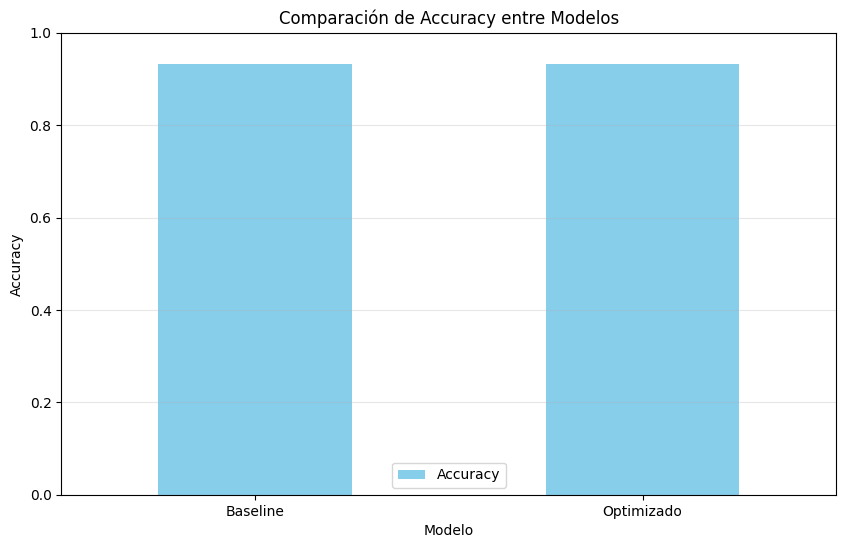

In [93]:
# Comparación visual de métricas
metrics_comparison = pd.DataFrame({
    'Baseline': [accuracy_baseline],
    'Optimizado': [accuracy_optimized]
}, index=['Accuracy'])

metrics_comparison.T.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightgreen'])
plt.title('Comparación de Accuracy entre Modelos')
plt.ylabel('Accuracy')
plt.xlabel('Modelo')
plt.xticks(rotation=0)
plt.legend(['Accuracy'])
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.show()

### Conclusiones y Análisis Final

## Narrativa del Análisis

En este notebook desarrollamos un modelo de clasificación completo para predecir el tipo de clima en Seattle. El proceso siguió una metodología rigurosa que incluyó:

**Fase 1 - Exploración:** Descubrimos que el dataset presenta un **desbalanceo significativo** entre clases, con algunas condiciones climáticas mucho más frecuentes que otras. Este desbalanceo podría causar que el modelo se sesgue hacia las clases mayoritarias.

**Fase 2 - Preparación:** Aplicamos **oversampling** para equilibrar las clases, asegurando que el modelo aprenda patrones de todas las categorías climáticas por igual. Esto es crucial para obtener buenas predicciones en todas las clases, no solo en las más frecuentes.

**Fase 3 - Modelado Baseline:** Creamos un árbol de decisión sin restricciones que logró un accuracy del **93.24%**. Sin embargo, este modelo generó un árbol complejo con 19 niveles de profundidad y 304 hojas, lo que sugiere posible sobreajuste.

**Fase 4 - Optimización:** Utilizamos GridSearchCV para buscar los mejores hiperparámetros entre 1,200 combinaciones posibles. Sorprendentemente, el proceso de optimización seleccionó parámetros que resultan en un árbol **más complejo** (20 niveles, 354 hojas) manteniendo el mismo accuracy.

**Resultado Clave:** Ambos modelos logran 93.24% de accuracy, pero el modelo "optimizado" es más complejo. Esto sugiere que:
- Los datos balanceados permiten mayor complejidad sin overfitting
- GridSearchCV priorizó accuracy sobre simplicidad
- La validación cruzada confirmó que esta complejidad es justificable

**Aprendizajes:**

1. **Balance de Clases:** El oversampling fue fundamental para obtener buenos resultados en todas las categorías climáticas

2. **Hiperparámetros vs Simplicidad:** La optimización automática no siempre favorece modelos más simples; el grid de búsqueda debe diseñarse según las prioridades del proyecto

3. **Accuracy como Métrica:** Un 93.24% es excelente para clasificación multiclase (5 categorías), indicando que las variables meteorológicas son buenos predictores

4. **Trade-offs:** Mayor complejidad implica mayor costo computacional y menor interpretabilidad, pero puede capturar patrones más sutiles

**Recomendaciones para Producción:**

- **Si la interpretabilidad es prioritaria:** Usar un grid más restrictivo (max_depth ≤ 10, max_leaf_nodes ≤ 100)
- **Si el accuracy es prioritario:** El modelo actual es adecuado
- **Validación continua:** Monitorear performance con datos nuevos para detectar degradación
- **Considerar ensemble methods:** Random Forest o Gradient Boosting podrían mejorar resultados

**Contexto Práctico:** Para una aplicación de predicción del clima, un accuracy del 93% significa que el modelo se equivoca aproximadamente 1 de cada 15 veces, lo cual es muy respetable considerando la naturaleza variable del clima.